In [21]:
from utils import *
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("bright")

In [22]:
experiments = [
    Experiment.basic_zero_plus_discr,
    Experiment.bell_state_reach,
    Experiment.bitflip_ipma,
    Experiment.reset,
    Experiment.ghz3
]

In [23]:
dfs = []
for experiment in experiments:
    path = get_paper_verification_path(experiment)
    df = pd.read_csv(path) # pyright: ignore
    df["experiment"] = get_nice_name(experiment)
    dfs.append(df) # pyright: ignore
    
df = pd.concat(dfs, ignore_index=True) # pyright: ignore
df


,hardware,embedding_index,horizon,method,time,result,threshold,experiment
0,cambridge,0,1,convex,0.01144,1,0.66185,state discr.
1,cambridge,0,2,convex,0.00506,1,0.66560,state discr.
2,cambridge,0,3,convex,0.00688,1,0.74436,state discr.
3,cambridge,0,4,convex,0.01270,1,0.74450,state discr.
4,cambridge,0,5,convex,0.02228,1,0.74866,state discr.
...,...,...,...,...,...,...,...,...
5814,quito,3,3,bellman,0.00684,1,0.90805,GHZ
5815,valencia,0,3,bellman,0.00629,1,0.97962,GHZ
5816,valencia,1,3,bellman,0.00647,1,0.97990,GHZ
5817,valencia,2,3,bellman,0.00652,1,0.97614,GHZ


In [29]:
df["experiment"] = df["experiment"].replace("Bell state reach", "local Bell state prep.")

In [30]:
df.describe()

,embedding_index,horizon,time,result,threshold
count,5819.000000,5819.000000,5819.000000,5819.000000,5819.000000
mean,7.725898,3.944492,0.033673,0.999313,0.824285
std,22.423070,1.859682,0.107055,0.026212,0.232577
min,0.000000,1.000000,0.000840,0.000000,0.000000
25%,0.000000,3.000000,0.006935,1.000000,0.676345
50%,1.000000,3.000000,0.014790,1.000000,0.953800
75%,2.000000,5.000000,0.032240,1.000000,0.983650
max,190.000000,9.000000,4.363260,1.000000,0.999000


In [31]:
bellman_df = df[df.method == "bellman"]
bellman_df


,hardware,embedding_index,horizon,method,time,result,threshold,experiment
654,algiers,0,1,bellman,0.00836,1,0.59719,local Bell state prep.
656,algiers,0,2,bellman,0.00552,1,0.59719,local Bell state prep.
658,algiers,0,3,bellman,0.01091,1,0.99120,local Bell state prep.
660,algiers,0,4,bellman,0.01734,1,0.99215,local Bell state prep.
662,algiers,0,5,bellman,0.03442,1,0.99592,local Bell state prep.
...,...,...,...,...,...,...,...,...
5814,quito,3,3,bellman,0.00684,1,0.90805,GHZ
5815,valencia,0,3,bellman,0.00629,1,0.97962,GHZ
5816,valencia,1,3,bellman,0.00647,1,0.97990,GHZ
5817,valencia,2,3,bellman,0.00652,1,0.97614,GHZ


In [32]:
convex_df = df[df.method == "convex"]
convex_df

,hardware,embedding_index,horizon,method,time,result,threshold,experiment
0,cambridge,0,1,convex,0.01144,1,0.66185,state discr.
1,cambridge,0,2,convex,0.00506,1,0.66560,state discr.
2,cambridge,0,3,convex,0.00688,1,0.74436,state discr.
3,cambridge,0,4,convex,0.01270,1,0.74450,state discr.
4,cambridge,0,5,convex,0.02228,1,0.74866,state discr.
...,...,...,...,...,...,...,...,...
4621,perfect_hardware,0,3,convex,0.00098,1,0.99900,Reset
4622,perfect_hardware,0,4,convex,0.00104,1,0.99900,Reset
4623,perfect_hardware,0,5,convex,0.00111,1,0.99900,Reset
4624,perfect_hardware,0,6,convex,0.00119,1,0.99900,Reset


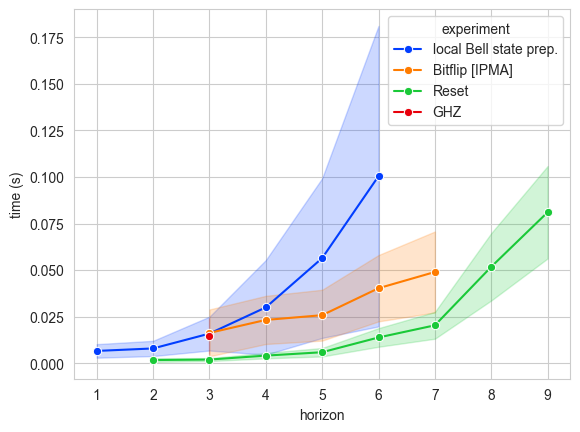

In [33]:
ax = sns.lineplot(bellman_df, x="horizon", y="time", hue="experiment", errorbar="sd", marker="o")
ax.set_ylabel("time (s)")
plt.savefig("figs/bellman_verify.pdf")

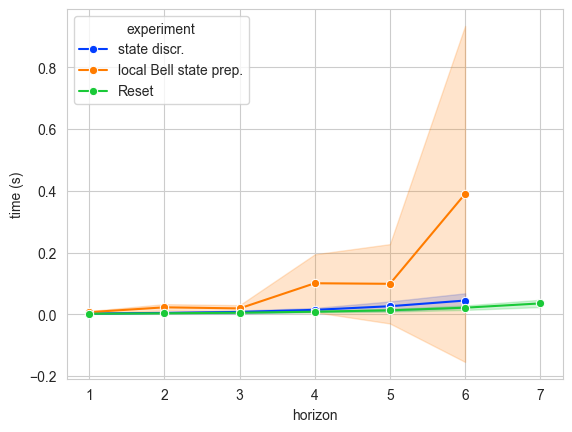

In [34]:
import matplotlib.pyplot as plt
ax = sns.lineplot(convex_df, x="horizon", y="time", hue="experiment", errorbar="sd", marker="o")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylabel("time (s)")
plt.savefig("figs/convex_verify.pdf")